In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
import camb
import scipy.interpolate as interp
from camb import model, initialpower

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
sigma 8 values at the two redshifts (fiducial): [0.54435417 0.79538453]
sigma 8 values at the two redshifts (modified): [0.74489639 1.09201096]


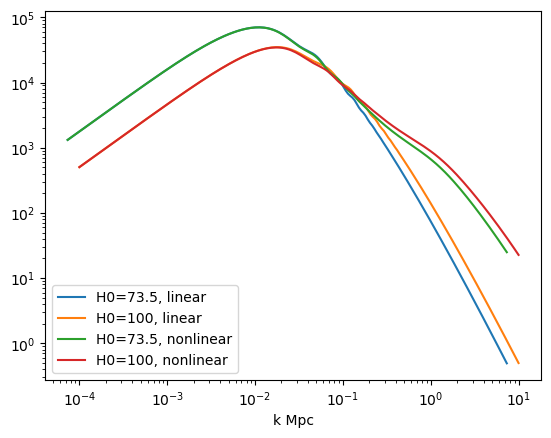

In [17]:
H0_1 = 73.5
H0_2 = 100
h1 = H0_1/100
h2 = H0_2/100
omch2 = 0.1174
ombh2 = 0.0255
omch2_new = omch2 * (h2/h1)**2
ombh2_new = ombh2 * (h2/h1)**2

pars1 = camb.set_params(H0=H0_1, ombh2=0.0225, omch2=0.1174, ns=0.969)
pars2 = camb.set_params(H0=H0_2, ombh2=ombh2_new, omch2=omch2_new, ns=0.969)
z1 = np.linspace(0,0.8,2)
z2 = np.linspace(0,0.8,2)
pars1.set_matter_power(z1, kmax=10.0)
pars2.set_matter_power(z2, kmax=10.0)
# Linear spectra
pars1.NonLinear = model.NonLinear_none
pars2.NonLinear = model.NonLinear_none
results1 = camb.get_results(pars1)
results2 = camb.get_results(pars2)
kh1, z1, pk1 = results1.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
kh2, z2, pk2 = results2.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)

# # Non-Linear spectra (Halofit)
pars1.NonLinear = model.NonLinear_both
pars2.NonLinear = model.NonLinear_both
results1.calc_power_spectra(pars1)
results2.calc_power_spectra(pars2)
kh_nonlin1, z_nonlin1, pk_nonlin1 = results1.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
kh_nonlin2, z_nonlin2, pk_nonlin2 = results2.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)

print('sigma 8 values at the two redshifts (fiducial):', results1.get_sigma8())
print('sigma 8 values at the two redshifts (modified):', results2.get_sigma8())

kh1 = kh1 * h1
kh2 = kh2 * h2
pk1 = pk1 / (h1)**3
pk2 = pk2 / (h2)**3

kh_nonlin1 = kh_nonlin1 * h1
kh_nonlin2 = kh_nonlin2 * h2
pk_nonlin1 = pk_nonlin1 / (h1)**3
pk_nonlin2 = pk_nonlin2 / (h2)**3
plt.loglog(kh1,pk1[0],label=f"H0={H0_1}, linear")
plt.loglog(kh2,pk2[0],label=f"H0={H0_2}, linear")
plt.loglog(kh_nonlin1,pk_nonlin1[0],label=f"H0={H0_1}, nonlinear"
#         #    , marker = '.'
           )
plt.loglog(kh_nonlin2,pk_nonlin2[0],label=f"H0={H0_2}, nonlinear"
#         #    , marker = '.'
           )
plt.xlabel('k Mpc')
plt.legend();